# Clasificación de Mortalidad Hospitalaria - Machine Learning supervisado

Machine Learning Supervisado

Objetivos:
- Identificar problemas que se pueden resolver usando Machine Learning supervisado.
- Implementar una solución de Machine Learning supervisado a problemas prácticos.
- Evaluar el desempeño de modelos de Machine Learning supervisado.
- Diseñar un clasificador que permita predecir la mortalidad de pacientes a partir de varias características fisiológicas, demográficas y de severidad de la enfermedad.


# Importe de librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, RocCurveDisplay
)

from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis


sns.set_style("whitegrid")


# Carga y preparación de datos

## Vista general

In [ ]:
# Configuración
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

# Cargar datos
df = pd.read_csv("data_train.csv")

# Dimensiones
print("Dimensiones del dataset:", df.shape)

# Primeras filas
display(df.head())

# Información general
display(df.info())

# Tipos de variables
display(df.dtypes)

# Distribución de la variable objetivo
print("\nDistribución de hospdead:")
display(df["hospdead"].value_counts(dropna=False))
display(df["hospdead"].value_counts(normalize=True, dropna=False))


Dimensiones del dataset: (9105, 27)


,Unnamed: 0,age,sex,dzgroup,dzclass,num.co,scoma,avtisst,race,sps,aps,surv2m,surv6m,hday,diabetes,dementia,ca,dnr,dnrday,meanbp,hrt,resp,temp,crea,sod,adlsc,hospdead
0,0,62.84998,male,Lung Cancer,Cancer,0,0.0,7.000000,other,33.898438,20.0,0.262939,0.036995,1,0,0,metastatic,no dnr,5.0,97.0,69.0,22.0,36.00000,1.199951,141.0,7.0,0
1,1,60.33899,female,Cirrhosis,COPD/CHF/Cirrhosis,2,44.0,29.000000,white,52.695312,74.0,0.001000,0.000000,3,0,0,no,NaN,NaN,43.0,112.0,34.0,34.59375,5.500000,132.0,1.0,1
2,2,52.74698,female,Cirrhosis,COPD/CHF/Cirrhosis,2,0.0,13.000000,white,20.500000,45.0,0.790894,0.664917,4,0,0,no,no dnr,17.0,70.0,88.0,28.0,37.39844,2.000000,134.0,0.0,0
3,3,42.38498,female,Lung Cancer,Cancer,2,0.0,7.000000,white,20.097656,19.0,0.698975,0.411987,1,0,0,metastatic,no dnr,3.0,75.0,88.0,32.0,35.00000,0.799927,139.0,0.0,0
4,4,79.88495,female,ARF/MOSF w/Sepsis,ARF/MOSF,1,26.0,18.666656,white,23.500000,30.0,0.634888,0.532959,3,0,0,no,no dnr,16.0,59.0,112.0,20.0,37.89844,0.799927,143.0,2.0,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9105 entries, 0 to 9104
Data columns (total 27 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  9105 non-null   int64  
 1   age         9105 non-null   float64
 2   sex         9105 non-null   object 
 3   dzgroup     9105 non-null   object 
 4   dzclass     9105 non-null   object 
 5   num.co      9105 non-null   int64  
 6   scoma       9104 non-null   float64
 7   avtisst     9023 non-null   float64
 8   race        9063 non-null   object 
 9   sps         9104 non-null   float64
 10  aps         9104 non-null   float64
 11  surv2m      9104 non-null   float64
 12  surv6m      9104 non-null   float64
 13  hday        9105 non-null   int64  
 14  diabetes    9105 non-null   int64  
 15  dementia    9105 non-null   int64  
 16  ca          9105 non-null   object 
 17  dnr         9075 non-null   object 
 18  dnrday      9075 non-null   float64
 19  meanbp      9104 non-null  

None

Unnamed: 0      int64
age           float64
sex            object
dzgroup        object
dzclass        object
num.co          int64
scoma         float64
avtisst       float64
race           object
sps           float64
aps           float64
surv2m        float64
surv6m        float64
hday            int64
diabetes        int64
dementia        int64
ca             object
dnr            object
dnrday        float64
meanbp        float64
hrt           float64
resp          float64
temp          float64
crea          float64
sod           float64
adlsc         float64
hospdead        int64
dtype: object


Distribución de hospdead:


hospdead
0    6745
1    2360
Name: count, dtype: int64

hospdead
0    0.740802
1    0.259198
Name: proportion, dtype: float64

El conjunto de datos contiene 9105 observaciones y 27 variables. La variable objetivo es `hospdead`, que indica mortalidad hospitalaria. Se observa que el problema presenta desbalance de clases, ya que la clase 0 es más frecuente (74%) que la clase 1 (26%). Por esta razón, además de accuracy, será necesario considerar métricas más informativas como recall, precision, F1-score y ROC-AUC.

Además, se excluyen aquellas variables que pueden actuar como identificadores o incorporar información demasiado cercana al desenlace final del paciente. En particular:

- `Unnamed: 0`: corresponde a un identificador del registro y no contiene señal clínica.
- `surv2m` y `surv6m`: representan probabilidades estimadas de supervivencia futuras, por lo que pueden introducir información derivada del pronóstico.
- `hday`: número total de días de hospitalización, variable que puede depender de la evolución final del paciente.
- `dnrday`: día en que se emitió la orden DNR, valor que ocurre durante la hospitalización y que no necesariamente estaría disponible al inicio de la predicción.

Con esto se construye un conjunto de variables más conservador, orientado a estimar un desempeño más realista en datos futuros.

In [ ]:
cols_to_drop = ["Unnamed: 0", "surv2m", "surv6m", "hday", "dnrday"]

df_model = df.drop(columns=cols_to_drop)

X = df_model.drop(columns="hospdead")
y = df_model["hospdead"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nVariables usadas:")
print(X.columns.tolist())


X shape: (9105, 21)
y shape: (9105,)

Variables usadas:
['age', 'sex', 'dzgroup', 'dzclass', 'num.co', 'scoma', 'avtisst', 'race', 'sps', 'aps', 'diabetes', 'dementia', 'ca', 'dnr', 'meanbp', 'hrt', 'resp', 'temp', 'crea', 'sod', 'adlsc']


## Datos faltantes

In [ ]:
missing_model = X.isna().sum().sort_values(ascending=False)
missing_model = missing_model[missing_model > 0]

missing_model_df = pd.DataFrame({
    "faltantes": missing_model,
    "porcentaje": (missing_model / len(X) * 100).round(4)
})

display(missing_model_df)


,faltantes,porcentaje
avtisst,82,0.9006
crea,67,0.7359
race,42,0.4613
dnr,30,0.3295
aps,1,0.0110
resp,1,0.0110
temp,1,0.0110
sod,1,0.0110
meanbp,1,0.0110
scoma,1,0.0110


Se identifican valores faltantes en varias variables, aunque en la mayoría de los casos la proporción es baja. Las variables con más faltantes deben tratarse con una estrategia de imputación apropiada, diferenciando entre variables numéricas y categóricas.

## Separación de variables categóricas y numéricas

In [ ]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object"]).columns.tolist()

print("Numéricas:", num_cols)
print("Categóricas:", cat_cols)


Numéricas: ['age', 'num.co', 'scoma', 'avtisst', 'sps', 'aps', 'diabetes', 'dementia', 'meanbp', 'hrt', 'resp', 'temp', 'crea', 'sod', 'adlsc']
Categóricas: ['sex', 'dzgroup', 'dzclass', 'race', 'ca', 'dnr']


## Transformación (OneHotEncoder) e imputación de datos faltantes

Dado que los faltantes son manejables, se utilizará imputación simple:
- Mediana para variables numéricas.
- Moda para variables categóricas.

Para realizar esta tarea de manera eficiente lo realizaremos mediante pipelines:

In [ ]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, num_cols),
    ("cat", categorical_transformer, cat_cols)
])


In [ ]:
# Preprocesador para GaussianNB / LDA / QDA
# Claves:
# - salida densa
# - drop='first' para reducir colinealidad en dummies
numeric_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer_dense = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False))
])

preprocessor_dense = ColumnTransformer(transformers=[
    ("num", numeric_transformer_dense, num_cols),
    ("cat", categorical_transformer_dense, cat_cols)
])

# Separación datos de entrenamiento y prueba
20% para prueba y 80% para entrenamiento:

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape, y_train.shape)
print("Test :", X_test.shape, y_test.shape)

Train: (7284, 21) (7284,)
Test : (1821, 21) (1821,)


# Modelos
Dado que el dataset contiene variables numéricas, categóricas y valores faltantes, se comparan cinco enfoques supervisados:

- Regresión logística regularizada.
- Random forest.
- Gaussian Naive Bayes.
- Linear Discriminant Analysis (LDA).
- Quadratic Discriminant Analysis (QDA).

Los tres últimos se incluyen como modelos generativos de referencia. Para GaussianNB, LDA y QDA se utiliza una versión densa del preprocesamiento con imputación, escalado y codificación one-hot, reduciendo además redundancia en variables categóricas con `drop='first'`.

La comparación se realiza usando ROC-AUC como criterio principal, complementado con recall, precision, F1 y accuracy. Se realiza esta elección ya que el problema presenta desbalance de clases y porque, en un contexto de mortalidad hospitalaria, los falsos negativos tienen relevancia clínica. Por ello, además del desempeño global, es importante examinar la sensibilidad del modelo sobre la clase positiva.


In [ ]:
models = {
    "logistic_regression": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42))
    ]),

    "random_forest": Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
    "gaussian_nb": Pipeline(steps=[
        ("preprocessor", preprocessor_dense),
        ("model", GaussianNB())
    ]),

    "lda": Pipeline(steps=[
        ("preprocessor", preprocessor_dense),
        ("model", LinearDiscriminantAnalysis(solver="lsqr", shrinkage="auto"))
    ]),

    "qda": Pipeline(steps=[
        ("preprocessor", preprocessor_dense),
        ("model", QuadraticDiscriminantAnalysis(reg_param=0.05))
    ])
}

## Selección del mejor modelo

In [ ]:
# validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "roc_auc": "roc_auc",
    "recall": "recall",
    "precision": "precision",
    "f1": "f1",
    "accuracy": "accuracy"
}

results = []

for name, pipe in models.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        error_score=np.nan
    )

    results.append({
        "modelo": name,
        "roc_auc_cv_mean": scores["test_roc_auc"].mean(),
        "recall_cv_mean": scores["test_recall"].mean(),
        "precision_cv_mean": scores["test_precision"].mean(),
        "f1_cv_mean": scores["test_f1"].mean(),
        "accuracy_cv_mean": scores["test_accuracy"].mean()
    })

results_df = pd.DataFrame(results).sort_values(by="roc_auc_cv_mean", ascending=False)
display(results_df)

,modelo,roc_auc_cv_mean,recall_cv_mean,precision_cv_mean,f1_cv_mean,accuracy_cv_mean
0,logistic_regression,0.939623,0.742053,0.821494,0.779480,0.891132
3,lda,0.938902,0.763774,0.800151,0.781257,0.889074
1,random_forest,0.931735,0.729349,0.810276,0.767609,0.885504
4,qda,0.897527,0.786552,0.686994,0.733187,0.851457
2,gaussian_nb,0.855165,0.795562,0.591085,0.677939,0.803955


Después de comparar los modelos candidatos, se seleccionó una regresión logística regularizada como modelo final. La selección se realizó usando validación cruzada estratificada de 5 particiones y ROC-AUC como métrica principal. Aunque LDA presentó un desempeño muy cercano, la regresión logística obtuvo el mejor resultado promedio.

## Búsqueda de hiperparámetros del mejor modelo

In [ ]:
pipe_lr = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(max_iter=2000, random_state=42))
])

param_grid_lr = {
    "model__C": [0.01, 0.1, 1, 10],
    "model__penalty": ["l2"],
    "model__class_weight": [None, "balanced"]
}

grid_lr = GridSearchCV(
    estimator=pipe_lr,
    param_grid=param_grid_lr,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    verbose=1
)

grid_lr.fit(X_train, y_train)

print("Best params:", grid_lr.best_params_)
print("Best CV ROC-AUC:", grid_lr.best_score_)
best_model = grid_lr.best_estimator_


Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'model__C': 0.1, 'model__class_weight': None, 'model__penalty': 'l2'}
Best CV ROC-AUC: 0.9396579764516233


El mejor conjunto de hiperparámetros fue:

- `penalty = l2`
- `C = 0.1`
- `class_weight = None`

Con esta configuración, el mejor desempeño promedio en validación cruzada fue:

- **ROC-AUC = 0.9397**

Este resultado indica que el modelo tiene una alta capacidad para discriminar entre pacientes que fallecen y pacientes que sobreviven durante la hospitalización.

# Evaluación en test
El modelo seleccionado se reentrena sobre el conjunto de entrenamiento completo y luego se evalua sobre el conjunto de prueba, que no fue utilizado durante el ajuste de hiperparámetros.

El desempeño en test se reporta mediante ROC-AUC, accuracy, precision, recall y F1, junto con la matriz de confusión y la curva ROC. Estas métricas permiten evaluar tanto la capacidad discriminativa general del modelo como su comportamiento específico sobre la clase positiva (`hospdead = 1`).

,metrica,valor
0,ROC-AUC,0.9466
1,Accuracy,0.9023
2,Precision,0.8568
3,Recall,0.7479
4,F1,0.7986


              precision    recall  f1-score   support

           0       0.92      0.96      0.94      1349
           1       0.86      0.75      0.80       472

    accuracy                           0.90      1821
   macro avg       0.89      0.85      0.87      1821
weighted avg       0.90      0.90      0.90      1821



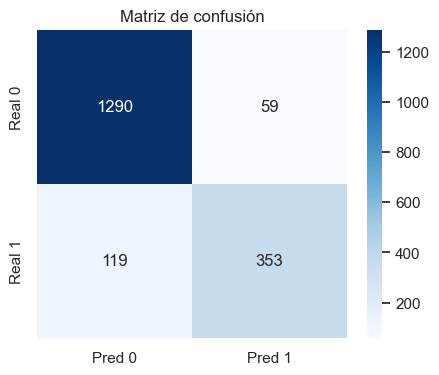

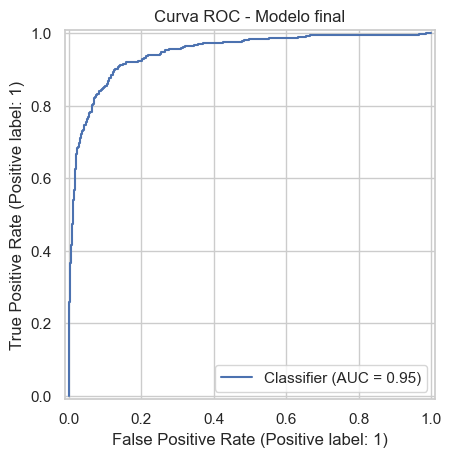

In [ ]:
best_model = grid_lr.best_estimator_

best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)
y_prob = best_model.predict_proba(X_test)[:, 1]

test_metrics = pd.DataFrame({
    "metrica": ["ROC-AUC", "Accuracy", "Precision", "Recall", "F1"],
    "valor": [
        roc_auc_score(y_test, y_prob),
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ]
})
test_metrics["valor"] = test_metrics["valor"].round(4)
display(test_metrics)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Real 0", "Real 1"],
    columns=["Pred 0", "Pred 1"]
)

plt.figure(figsize=(5,4))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de confusión")
plt.show()

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Curva ROC - Modelo final")
plt.show()


Los resultados obtenidos en test fueron:

- **ROC-AUC:** 0.9466
- **Accuracy:** 0.9023
- **Precision:** 0.8568
- **Recall:** 0.7479
- **F1-score:** 0.7986

Estos resultados indican que el modelo posee una alta capacidad discriminativa para distinguir entre pacientes que fallecen y pacientes que sobreviven durante la hospitalización. En particular, el valor de ROC-AUC cercano a 0.95 muestra un muy buen desempeño global.

La matriz de confusión obtenida fue:

- Verdaderos negativos: 1290
- Falsos positivos: 59
- Falsos negativos: 119
- Verdaderos positivos: 353

Esto muestra que el modelo identifica correctamente la mayoría de los pacientes supervivientes y también detecta una proporción importante de los pacientes que fallecen. Sin embargo, los 119 falsos negativos indican que todavía existe margen de mejora en la detección de pacientes de alto riesgo, por lo que el recall de la clase positiva sigue siendo una métrica especialmente relevante en este contexto.

Adicionalmente, el ROC-AUC en test (0.9466) fue consistente con el mejor ROC-AUC obtenido en validación cruzada (0.9397), lo que sugiere que el modelo generaliza adecuadamente y no presenta evidencia fuerte de sobreajuste.

# Análisis y conclusiones

La regresión logística regularizada presentó el mejor desempeño global, con resultados consistentes entre validación cruzada y conjunto de prueba. En la comparación ampliada con random forest, GaussianNB, LDA y QDA, la regresión logística obtuvo el mayor ROC-AUC promedio en validación cruzada, aunque LDA mostró un desempeño muy cercano, lo que sugiere que la estructura del problema puede capturarse razonablemente bien con fronteras de decisión lineales.

El modelo final ajustado mediante búsqueda de hiperparámetros alcanzó un ROC-AUC de 0.9466 en test, junto con una precisión alta y un recall aceptable para la clase positiva. Esto indica una muy buena capacidad discriminativa para estratificar riesgo de mortalidad hospitalaria, aunque la presencia de 119 falsos negativos muestra que aún existe margen de mejora en la detección de todos los pacientes de mayor riesgo.

Desde el punto de vista metodológico, el uso de pipelines con imputación, escalado y codificación permitió un preprocesamiento consistente y reproducible. Además, la regularización contribuyó a controlar la complejidad del modelo y favoreció una buena capacidad de generalización.

Los modelos generativos incorporados aportaron valor como referencia comparativa. Sin embargo, sus supuestos distribucionales son más exigentes en un problema con variables continuas, variables categóricas codificadas y posible heterogeneidad entre clases, por lo que su utilidad principal en este trabajo fue enriquecer el proceso de selección del modelo final.


